# 03 - Ingeniería de Variables para Series de Tiempo

**Módulo 3 - Series de Tiempo | ML Avanzado**

Los modelos de ML (XGBoost, redes, regresión lineal...) no entienden de
"series": entienden de **tablas**. El puente es reformular el pronóstico como
**regresión supervisada**:

$$
y_t = f\big(\underbrace{y_{t-1}, y_{t-7}, \dots}_{\text{rezagos}},\;
\underbrace{\bar y_{t-7:t-1}, \dots}_{\text{ventanas móviles}},\;
\underbrace{\text{día, mes, Fourier}}_{\text{calendario}}\big) + \varepsilon_t
$$

Este notebook construye esa matriz de variables **sin fuga temporal** y la
valida con un modelo lineal. La regla de oro:

> **Toda variable de la fila $t$ debe poder calcularse usando solo información
> disponible antes de $t$** (o información de calendario, que se conoce por
> adelantado).

In [14]:
import os, sys, warnings
warnings.filterwarnings("ignore")

# Hacemos importable utils/ tanto si el notebook corre desde notebooks/ como
# desde la raíz del repositorio.
_here = os.getcwd()
for cand in (os.path.join(_here, "..", "utils"), os.path.join(_here, "utils"),
             os.path.join(_here, "..", "..", "module3-time-series", "utils")):
    cand = os.path.abspath(cand)
    if os.path.isdir(cand) and cand not in sys.path:
        sys.path.insert(0, cand)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from mlflow_helpers import setup_mlflow, log_and_register, register_best_run

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
np.random.seed(42)
print("Versión de MLflow:", mlflow.__version__)

Versión de MLflow: 3.14.0


In [15]:
# ---------------------------------------------------------------------------
# Carga del dataset UCI #235 (con caché local y respaldo sintético offline)
# ---------------------------------------------------------------------------
import io, zipfile, urllib.request

UCI_ZIP_URL = ("https://archive.ics.uci.edu/static/public/235/"
               "individual+household+electric+power+consumption.zip")

def _data_dir():
    for cand in ("../data", "data", "module3-time-series/data"):
        cand = os.path.abspath(cand)
        if os.path.isdir(cand):
            return cand
    cand = os.path.abspath("../data")
    os.makedirs(cand, exist_ok=True)
    return cand

DATA_DIR = _data_dir()
DAILY_CSV = os.path.join(DATA_DIR, "household_power_daily.csv")
HOURLY_CSV = os.path.join(DATA_DIR, "household_power_hourly.csv")

def load_household_power():
    """Devuelve (daily, hourly): potencia activa global media, en kW."""
    if os.path.isfile(DAILY_CSV) and os.path.isfile(HOURLY_CSV):
        daily = pd.read_csv(DAILY_CSV, index_col=0, parse_dates=True).iloc[:, 0]
        hourly = pd.read_csv(HOURLY_CSV, index_col=0, parse_dates=True).iloc[:, 0]
        return daily.asfreq("D"), hourly.asfreq("h")

    print("Descargando el dataset UCI #235 (~20 MB)...")
    raw = urllib.request.urlopen(UCI_ZIP_URL, timeout=180).read()
    with zipfile.ZipFile(io.BytesIO(raw)) as zf:
        with zf.open("household_power_consumption.txt") as fh:
            df = pd.read_csv(fh, sep=";", na_values=["?"], low_memory=False,
                             usecols=["Date", "Time", "Global_active_power"])
    ts = pd.to_datetime(df["Date"] + " " + df["Time"],
                        format="%d/%m/%Y %H:%M:%S")
    power = pd.Series(df["Global_active_power"].astype(float).to_numpy(),
                      index=ts, name="global_active_power_kw").sort_index()

    # Agregamos y rellenamos huecos por interpolación temporal (~1.25% de
    # minutos faltantes + un par de cortes de varios días).
    daily = power.resample("D").mean().interpolate(method="time")
    hourly = power.resample("h").mean().interpolate(method="time")
    daily = daily.iloc[1:-1]                       # primer/último día parciales
    hourly = hourly.loc[daily.index.min():
                        daily.index.max() + pd.Timedelta(hours=23)]
    daily.to_frame().to_csv(DAILY_CSV)
    hourly.to_frame().to_csv(HOURLY_CSV)
    return daily.asfreq("D"), hourly.asfreq("h")

try:
    daily, hourly = load_household_power()
    print(f"daily : {daily.index.min().date()} .. {daily.index.max().date()} "
          f"(n={len(daily)})")
    print(f"hourly: n={len(hourly)}")
except Exception as e:
    print("No se pudo descargar el dataset:", repr(e))
    print("Usando RESPALDO SINTÉTICO (estacionalidad semanal + anual).")
    rng = np.random.default_rng(7)
    idx = pd.date_range("2006-12-17", "2010-11-25", freq="D")
    t = np.arange(len(idx))
    daily = pd.Series(
        1.1
        + 0.35 * np.cos(2 * np.pi * (t - 20) / 365.25)   # invierno alto
        + 0.10 * (idx.dayofweek >= 5)                     # fin de semana
        + rng.normal(0, 0.12, len(idx)),
        index=idx, name="global_active_power_kw").clip(lower=0.1).asfreq("D")
    hidx = pd.date_range(idx.min(), idx.max() + pd.Timedelta(hours=23), freq="h")
    hh = hidx.hour.to_numpy()
    base = daily.reindex(pd.DatetimeIndex(hidx.date)).to_numpy()
    profile = 0.6 + 0.35 * np.sin(2 * np.pi * (hh - 14) / 24) \
              + 0.25 * ((hh >= 18) & (hh <= 22))
    hourly = pd.Series(base * profile + rng.normal(0, 0.05, len(hidx)),
                       index=hidx, name=daily.name).clip(lower=0.05).asfreq("h")

daily : 2006-12-17 .. 2010-11-25 (n=1440)
hourly: n=34560


In [16]:
# ---------------------------------------------------------------------------
# Métricas de pronóstico + gráfico estándar — se usan en TODOS los notebooks.
# ---------------------------------------------------------------------------
def forecast_metrics(y_true, y_pred):
    """MSE, RMSE, MAE, MAPE y sMAPE como dict {nombre: float}."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err = y_true - y_pred
    mse = float(np.mean(err ** 2))
    return {
        "MSE":   mse,
        "RMSE":  float(np.sqrt(mse)),
        "MAE":   float(np.mean(np.abs(err))),
        "MAPE":  float(np.mean(np.abs(err) / np.abs(y_true)) * 100.0),
        "sMAPE": float(np.mean(2.0 * np.abs(err)
                               / (np.abs(y_true) + np.abs(y_pred))) * 100.0),
    }

def print_metrics(name, m):
    print(f"{name:<26s} MSE={m['MSE']:.4f}  RMSE={m['RMSE']:.4f}  "
          f"MAE={m['MAE']:.4f}  MAPE={m['MAPE']:.2f}%  sMAPE={m['sMAPE']:.2f}%")

def metrics_table(metrics_by_model):
    """dict {modelo: dict_de_métricas} -> DataFrame ordenado por sMAPE."""
    return (pd.DataFrame(metrics_by_model).T
            .sort_values("sMAPE").round(4))

def plot_forecast(train, test, forecasts, title="", tail=180, ci=None):
    """Cola del train + test real + uno o varios pronósticos.

    forecasts : dict {nombre: pd.Series indexada como test}
    ci        : tupla opcional (lower, upper) para una banda de confianza
    Devuelve la figura (útil para loggearla en MLflow).
    """
    fig, ax = plt.subplots(figsize=(13, 5))
    train.iloc[-tail:].plot(ax=ax, label="train (cola)", color="0.65")
    test.plot(ax=ax, label="real (test)", color="black", lw=2)
    for name, fc in forecasts.items():
        fc.plot(ax=ax, label=name, lw=1.8)
    if ci is not None:
        ax.fill_between(test.index, ci[0], ci[1], alpha=0.2, label="IC 95%")
    ax.set_title(title)
    ax.set_ylabel("potencia activa media (kW)")
    ax.legend()
    plt.tight_layout()
    plt.show()
    return fig

## 1. Rezagos (*lags*)

El rezago $k$ es simplemente $y_{t-k}$. ¿Cuáles incluir? Los que la propia
serie sugiera: la **ACF** nos dice qué rezagos correlacionan con el presente.
Para una serie diaria con semana y año: $1, 2, 3$ (persistencia de corto
plazo), $7, 14, 28$ (estacionalidad semanal) y $365$ (estacionalidad anual).

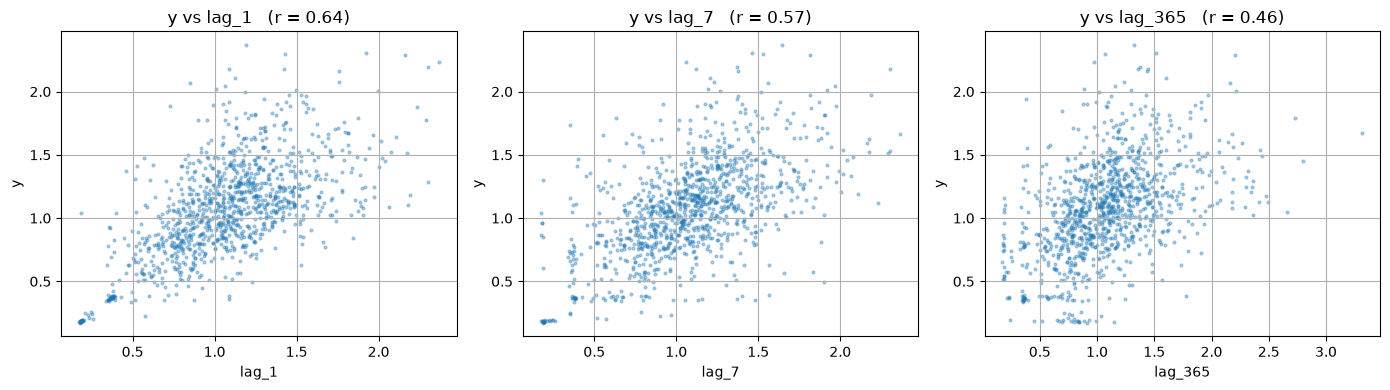

In [17]:
lags_df = pd.DataFrame({
    "y": daily,
    "lag_1": daily.shift(1),
    "lag_7": daily.shift(7),
    "lag_365": daily.shift(365),
}).dropna()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, lag in zip(axes, ["lag_1", "lag_7", "lag_365"]):
    ax.scatter(lags_df[lag], lags_df["y"], s=4, alpha=0.35)
    r = lags_df["y"].corr(lags_df[lag])
    ax.set_title(f"y vs {lag}   (r = {r:.2f})")
    ax.set_xlabel(lag); ax.set_ylabel("y")
plt.tight_layout(); plt.show()

## 2. Estadísticos de ventana móvil

Media, desviación, mínimo y máximo sobre una ventana **del pasado**:

$$
\text{rollmean}_w(t) = \frac{1}{w} \sum_{i=1}^{w} y_{t-i}
$$

Codifican el **nivel local** y la **volatilidad local** suavizando el ruido.

⚠️ **La trampa de fuga más común**: `y.rolling(7).mean()` en la fila $t$
**incluye $y_t$** — ¡la variable contiene la respuesta! La solución es
desplazar primero: `y.shift(1).rolling(7).mean()`.

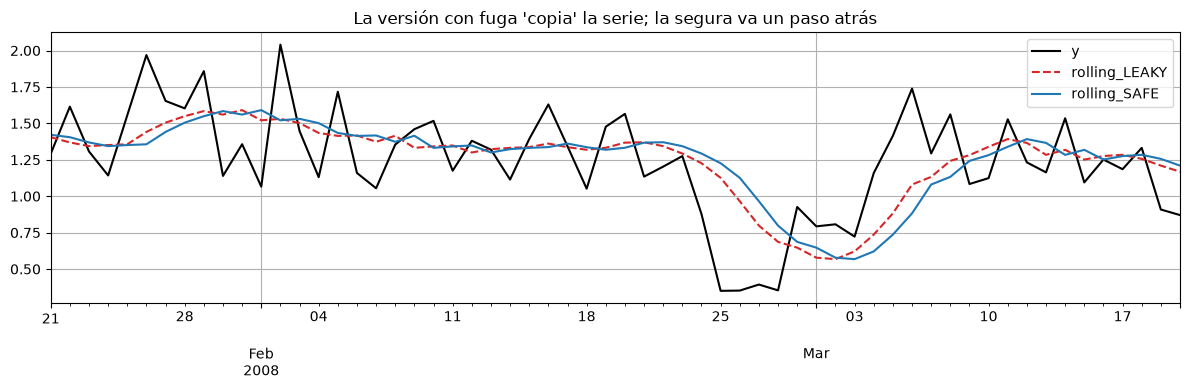

corr(y, leaky) = 0.7551  | corr(y, safe) = 0.6722


In [18]:
# MAL  (fuga): la ventana de la fila t incluye y_t
leaky = daily.rolling(7).mean()
# BIEN (sin fuga): primero shift(1), la ventana termina en t-1
safe = daily.shift(1).rolling(7).mean()

comp = pd.DataFrame({"y": daily, "rolling_LEAKY": leaky,
                     "rolling_SAFE": safe}).iloc[400:460]
ax = comp.plot(figsize=(12, 4), style=["k-", "C3--", "C0-"])
ax.set_title("La versión con fuga 'copia' la serie; la segura va un paso atrás")
plt.tight_layout(); plt.show()

print("corr(y, leaky) =", round(daily.corr(leaky), 4),
      " | corr(y, safe) =", round(daily.corr(safe), 4))

## 3. Variables de calendario

El calendario se conoce **por adelantado**, así que no hay riesgo de fuga:
día de la semana, mes, fin de semana, festivos... En este hogar el efecto
fin de semana es visible (más tiempo en casa).

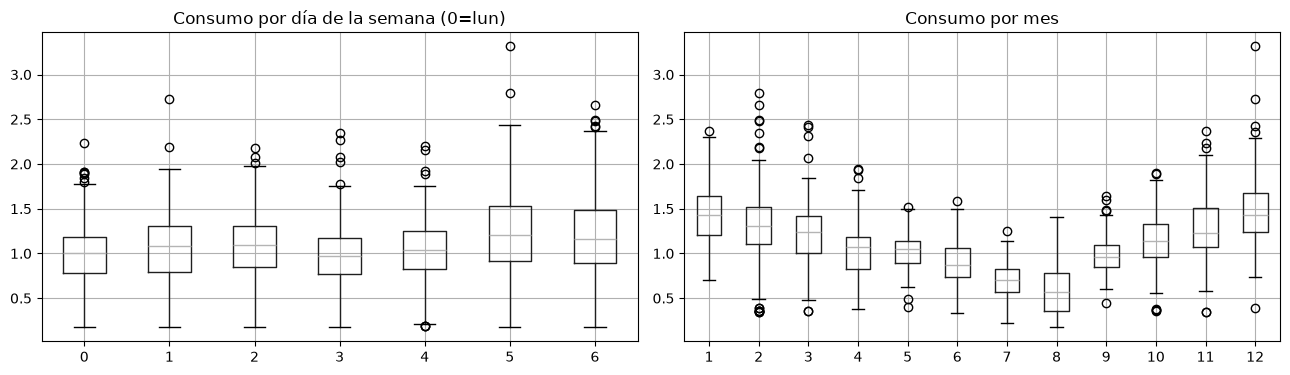

In [19]:
cal = pd.DataFrame({"y": daily,
                    "dayofweek": daily.index.dayofweek,
                    "month": daily.index.month})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
cal.boxplot(column="y", by="dayofweek", ax=axes[0])
axes[0].set_title("Consumo por día de la semana (0=lun)"); axes[0].set_xlabel("")
cal.boxplot(column="y", by="month", ax=axes[1])
axes[1].set_title("Consumo por mes"); axes[1].set_xlabel("")
fig.suptitle("")
plt.tight_layout(); plt.show()

## 4. Estacionalidad de Fourier

Los enteros de calendario (`month = 1..12`) imponen un **orden falso**
(diciembre y enero quedan "lejos" siendo vecinos). Para efectos periódicos
suaves usamos **términos de Fourier** de periodo $m$:

$$
\sin\!\Big(\frac{2\pi k t}{m}\Big), \quad
\cos\!\Big(\frac{2\pi k t}{m}\Big), \qquad k = 1, \dots, K .
$$

Unos pocos armónicos $K$ aproximan cualquier forma estacional suave, y además
le dan a los modelos de árboles una representación **continua** del ciclo
anual. Demostración: regresión lineal solo con Fourier anual ($K=3$).

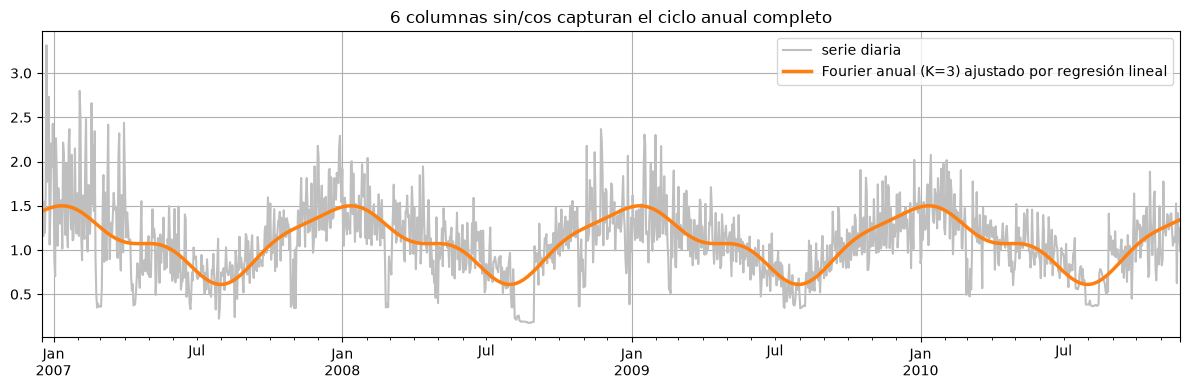

In [20]:
from sklearn.linear_model import LinearRegression

t_idx = np.arange(len(daily))
Xf = np.column_stack(
    [np.sin(2 * np.pi * k * t_idx / 365.25) for k in (1, 2, 3)] +
    [np.cos(2 * np.pi * k * t_idx / 365.25) for k in (1, 2, 3)])
smooth = LinearRegression().fit(Xf, daily.values).predict(Xf)

fig, ax = plt.subplots(figsize=(12, 4))
daily.plot(ax=ax, color="0.75", label="serie diaria")
ax.plot(daily.index, smooth, color="C1", lw=2.5,
        label="Fourier anual (K=3) ajustado por regresión lineal")
ax.set_title("6 columnas sin/cos capturan el ciclo anual completo")
ax.legend(); plt.tight_layout(); plt.show()

## 5. La matriz de variables completa

Juntamos todo en una función. **Esta misma función se reutiliza en los
notebooks 04 (XGBoost) y 05 (ensambles)** — en producción viviría en un
*feature store* (Módulo 1).

In [22]:
# ---------------------------------------------------------------------------
# Matriz de variables supervisada para pronóstico diario (sin fuga temporal).
# Construida y explicada en el notebook 03 — aquí la reutilizamos tal cual.
# ---------------------------------------------------------------------------
def make_features(s, lags=(1, 2, 3, 7, 14, 28, 365),
                  roll_windows=(7, 28), fourier=((7, 2), (365.25, 3))):
    df = pd.DataFrame({"y": s})
    df["t_index"] = np.arange(len(df))

    # rezagos
    for L in lags:
        df[f"lag_{L}"] = df["y"].shift(L)

    # estadísticos móviles SOLO del pasado: shift(1) antes de rolling
    past = df["y"].shift(1)
    for w in roll_windows:
        df[f"rollmean_{w}"] = past.rolling(w).mean()
        df[f"rollstd_{w}"] = past.rolling(w).std()
        df[f"rollmin_{w}"] = past.rolling(w).min()
        df[f"rollmax_{w}"] = past.rolling(w).max()

    # calendario
    df["dayofweek"] = df.index.dayofweek
    df["month"] = df.index.month
    df["is_weekend"] = (df.index.dayofweek >= 5).astype(int)

    # estacionalidad de Fourier (semanal y anual)
    tt = df["t_index"].to_numpy()
    for period, K in fourier:
        for k in range(1, K + 1):
            df[f"sin_{int(period)}_{k}"] = np.sin(2 * np.pi * k * tt / period)
            df[f"cos_{int(period)}_{k}"] = np.cos(2 * np.pi * k * tt / period)
    return df

In [9]:
feat = make_features(daily).dropna()
X, y = feat.drop(columns=["y"]), feat["y"]
print("matriz de variables:", X.shape, "| primeras columnas:", list(X.columns[:8]))
feat.head(3)

matriz de variables: (1075, 29) | primeras columnas: ['t_index', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_28', 'lag_365']


,y,t_index,lag_1,lag_2,lag_3,lag_7,lag_14,lag_28,lag_365,rollmean_7,...,sin_7_1,cos_7_1,sin_7_2,cos_7_2,sin_365_1,cos_365_1,sin_365_2,cos_365_2,sin_365_3,cos_365_3
2007-12-17,1.248830,365,1.918207,1.900608,1.371394,1.221357,1.223653,1.196982,2.354486,1.485473,...,0.781831,0.623490,0.974928,-0.222521,-0.004301,0.999991,-0.008601,0.999963,-0.012901,0.999917
2007-12-18,1.821662,366,1.248830,1.918207,1.900608,1.600767,1.435858,1.455456,1.530435,1.489398,...,0.974928,-0.222521,-0.433884,-0.900969,0.012901,0.999917,0.025801,0.999667,0.038696,0.999251
2007-12-19,1.525036,367,1.821662,1.248830,1.918207,1.102821,1.495222,1.217398,1.157079,1.520954,...,0.433884,-0.900969,-0.781831,0.623490,0.030100,0.999547,0.060172,0.998188,0.090190,0.995925


## 6. Validación consciente del tiempo

**¿Por qué no k-fold aleatorio?** Mezclaría filas del futuro en el
entrenamiento (los rezagos del fold de validación aparecen como objetivo en el
de entrenamiento y viceversa) → puntajes optimistas que se desploman en
producción. En series de tiempo **la validación siempre va después del
entrenamiento**:

- **Ventana expansiva** — `TimeSeriesSplit`: el train crece, se valida el
  siguiente tramo.
- **Ventana deslizante** — train de tamaño fijo que avanza.

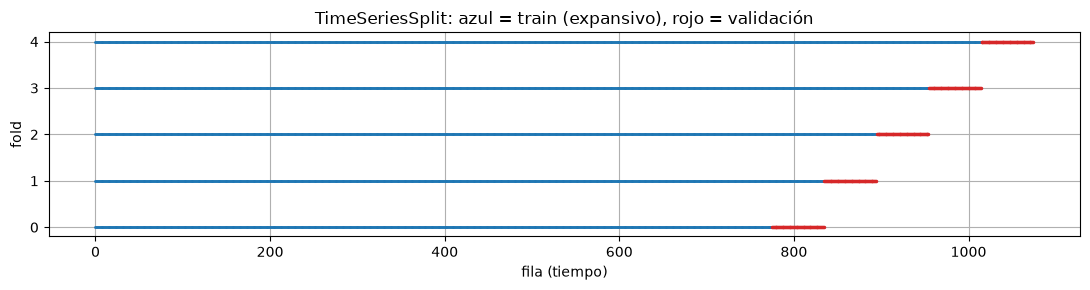

In [23]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5, test_size=60)
fig, ax = plt.subplots(figsize=(11, 3))
for i, (tr, va) in enumerate(tscv.split(X)):
    ax.plot(tr, [i] * len(tr), ".", color="C0", markersize=2)
    ax.plot(va, [i] * len(va), ".", color="C3", markersize=3)
ax.set_yticks(range(5)); ax.set_ylabel("fold"); ax.set_xlabel("fila (tiempo)")
ax.set_title("TimeSeriesSplit: azul = train (expansivo), rojo = validación")
plt.tight_layout(); plt.show()

## 7. Sanity check: ¿las variables tienen señal?

Un modelo **lineal regularizado (Ridge)** sobre la matriz de variables. Si
esta base tan simple ya vence a los baselines del notebook 01, la ingeniería
de variables está funcionando. Evaluamos a **1 paso** sobre los últimos 60
días (predicción del día $t$ usando los valores *reales* hasta $t-1$; el
multi-paso "honesto" llega en el notebook 04).

RMSE por fold: [0.2739, 0.3254, 0.176, 0.1801, 0.2057] | promedio: 0.2322
Ridge (1 paso)             MSE=0.0927  RMSE=0.3045  MAE=0.2244  MAPE=20.69%  sMAPE=19.46%


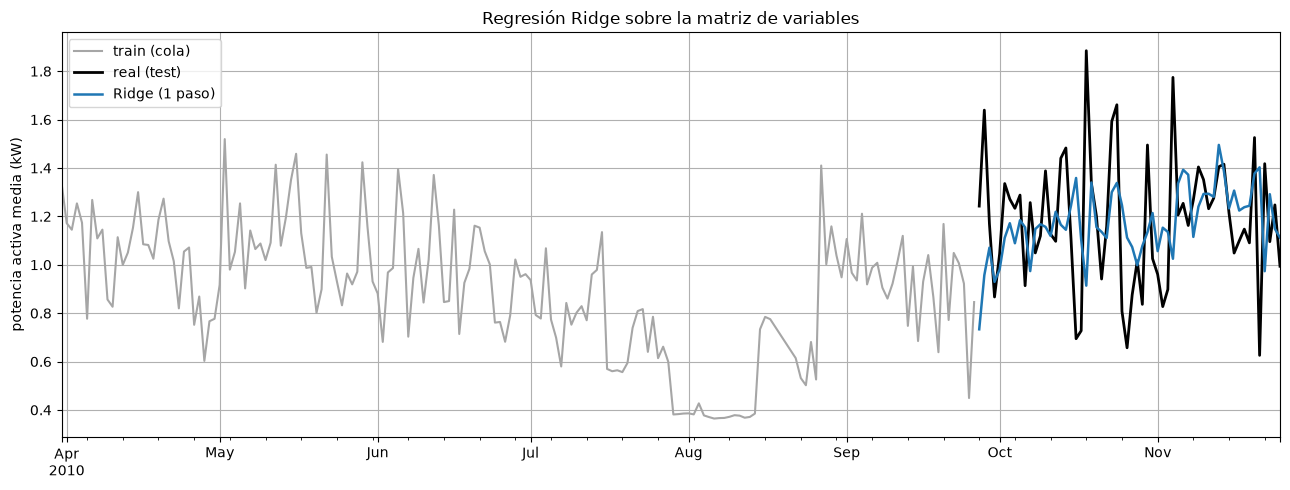

In [24]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

H = 60
X_train, X_test = X.iloc[:-H], X.iloc[-H:]
y_train, y_test = y.iloc[:-H], y.iloc[-H:]

ridge = make_pipeline(StandardScaler(), Ridge(alpha=10.0))

cv_rmse = []
for tr, va in tscv.split(X_train):
    ridge.fit(X_train.iloc[tr], y_train.iloc[tr])
    pred = ridge.predict(X_train.iloc[va])
    cv_rmse.append(float(np.sqrt(np.mean((y_train.iloc[va] - pred) ** 2))))
print("RMSE por fold:", [round(s, 4) for s in cv_rmse],
      "| promedio:", round(np.mean(cv_rmse), 4))

ridge.fit(X_train, y_train)
pred_test = pd.Series(ridge.predict(X_test), index=y_test.index)

ridge_metrics = forecast_metrics(y_test, pred_test)
print_metrics("Ridge (1 paso)", ridge_metrics)

fig_ridge = plot_forecast(y_train, y_test, {"Ridge (1 paso)": pred_test},
                          title="Regresión Ridge sobre la matriz de variables")

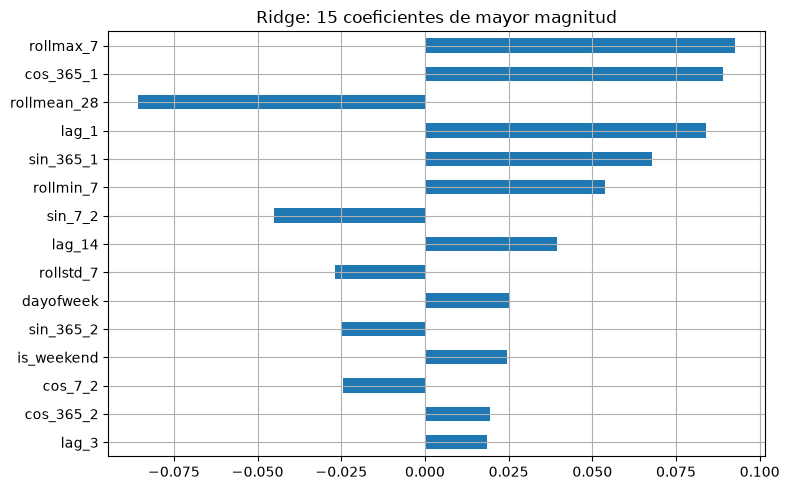

In [25]:
# ¿Qué variables pesan más? (coeficientes sobre variables estandarizadas)
coefs = pd.Series(ridge.named_steps["ridge"].coef_, index=X.columns)
ax = coefs.reindex(coefs.abs().sort_values().index).tail(15).plot(
    kind="barh", figsize=(8, 5))
ax.set_title("Ridge: 15 coeficientes de mayor magnitud")
plt.tight_layout(); plt.show()

## 8. Registro en MLflow y exportación de la matriz

In [26]:
setup_mlflow("module3-03-feature-engineering", backend="dagshub")

FEATURES_CSV = os.path.join(DATA_DIR, "household_features_daily.csv")
feat.to_csv(FEATURES_CSV)
print("matriz exportada a", FEATURES_CSV)

log_and_register(
    run_name="ridge-feature-sanity-check",
    params={"model": "Ridge", "alpha": 10.0, "n_features": X.shape[1],
            "eval": "one-step-ahead", "horizon_days": H,
            "dataset": "uci-household-power"},
    metrics={**ridge_metrics, "cv_rmse_mean": float(np.mean(cv_rmse))},
    model=ridge,
    flavor="sklearn",
    input_example=X_test.head(3),
    tags={"notebook": "03_feature_engineering"},
    figures={"plots/forecast.png": fig_ridge},
    artifact_files={FEATURES_CSV: "features"},
)

[mlflow_helpers] Backend      : local
[mlflow_helpers] Tracking URI : sqlite:////Users/miguelarquezabdala/repos/dsrp-machine-learning-engineering-20262/module3-time-series/notebooks/mlruns.db
[mlflow_helpers] Experiment   : module3-03-feature-engineering
matriz exportada a /Users/miguelarquezabdala/repos/dsrp-machine-learning-engineering-20262/module3-time-series/data/household_features_daily.csv


2026/08/03 20:46:02 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


'2ed2dbf33aff4c2dbe918af640605530'

## Resumen

- El pronóstico con ML = **regresión supervisada** sobre una matriz de
  variables construida solo con el pasado + calendario.
- Tres familias: **rezagos** (guiados por la ACF), **ventanas móviles** (con
  `shift(1)` — la trampa de fuga nº 1) y **calendario/Fourier** (los términos
  $\sin/\cos$ evitan el orden falso de los enteros y capturan ciclos suaves).
- Valida con **`TimeSeriesSplit`**, nunca con k-fold aleatorio.
- Un Ridge sobre estas variables ya compite — la matriz queda exportada y la
  función `make_features` se reutiliza en los notebooks 04 y 05.

Siguiente: **04 — XGBoost para pronóstico** (multi-paso recursivo, importancia
de variables, registry).